<span style="font-size:25px; font-weight:bold">Name: Wondwosen Muhea</span><br>
<span style="font-size:20px; font-weight:bold">Course: Advanced Big Data and Data Mining (MSCS-634-M40) </span><br>
<span style="font-size:16px; font-weight:bold">Lab 4: Regression Analysis with Regularization Techniques</span><br>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix, homogeneity_score, completeness_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from scipy.stats import mode
import matplotlib.pyplot as plt

In [2]:
# Load the Wine dataset
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
# Convert to DataFrame for easier inspection
df = pd.DataFrame(X, columns=feature_names)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Optionally convert scaled data to DataFrame
df_scaled = pd.DataFrame(X_scaled, columns=feature_names)
df_scaled.head()
print("Data description")
df_scaled.describe()

Data description


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02
mean,7.943708e-15,3.592632e-16,-4.066660e-15,-7.983626e-17,-7.983626e-17,-3.991813e-17,9.979533e-16,-5.588538e-16,-1.656602e-15,-3.442939e-16,1.636643e-15,2.235415e-15,-1.197544e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00
min,-2.434235e+00,-1.432983e+00,-3.679162e+00,-2.671018e+00,-2.088255e+00,-2.107246e+00,-1.695971e+00,-1.868234e+00,-2.069034e+00,-1.634288e+00,-2.094732e+00,-1.895054e+00,-1.493188e+00
25%,-7.882448e-01,-6.587486e-01,-5.721225e-01,-6.891372e-01,-8.244151e-01,-8.854682e-01,-8.275393e-01,-7.401412e-01,-5.972835e-01,-7.951025e-01,-7.675624e-01,-9.522483e-01,-7.846378e-01
50%,6.099988e-02,-4.231120e-01,-2.382132e-02,1.518295e-03,-1.222817e-01,9.595986e-02,1.061497e-01,-1.760948e-01,-6.289785e-02,-1.592246e-01,3.312687e-02,2.377348e-01,-2.337204e-01
75%,8.361286e-01,6.697929e-01,6.981085e-01,6.020883e-01,5.096384e-01,8.089974e-01,8.490851e-01,6.095413e-01,6.291754e-01,4.939560e-01,7.131644e-01,7.885875e-01,7.582494e-01
max,2.259772e+00,3.109192e+00,3.156325e+00,3.154511e+00,4.371372e+00,2.539515e+00,3.062832e+00,2.402403e+00,3.485073e+00,3.435432e+00,3.301694e+00,1.960915e+00,2.971473e+00


#### Analysis of Scaling
Why We Scale Data Before Hierarchical Clustering
- Hierarchical clustering and most distance-based algorithms in gerneal relies on computing distances between data points.
- Agglomerative clustering often uses Euclidean distance
- Features with larger numeric ranges dominate the distance calculation if not scaled
Scaling Solves
- All features contribute equally to distance
- Clustering reflects true structure, not value magnitude

In [3]:
# Evaluate Hierarchical clustering with different number of clusters
cluster_range = range(2, 6)
silhouette_scores = []
ari_scores = []

for n_clusters in cluster_range:
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)
    
    if n_clusters == 3:
        ari = adjusted_rand_score(y, labels)
        best_labels = labels  # Save for confusion matrix and PCA plot
    else:
        ari = np.nan
    ari_scores.append(ari)

# Create summary DataFrame
evaluation_df = pd.DataFrame({
    'n_clusters': list(cluster_range),
    'silhouette_score': silhouette_scores,
    'adjusted_rand_index': ari_scores
})

# Display table
print("Agglomerative Clustering Evaluation")
display(evaluation_df)

Agglomerative Clustering Evaluation


,n_clusters,silhouette_score,adjusted_rand_index
0,2,0.267013,NaN
1,3,0.277444,0.789933
2,4,0.225837,NaN
3,5,0.186742,NaN


#### Analysis
Silhouette Score
- have values (-1 to 1) indicates how well each point fits within its cluster.
- value Close to 1 = well-clustered and 0 = overlapping clusters with Negative value = wrong clustering
- In the above results: Best silhouette score is at 3 clusters (0.2774)
- Score drops as clusters increase beyond 3 (over-segmentation)

Adjusted Rand Index (ARI)

- Measures clustering accuracy vs ground truth labels with values between -1 to 1
- 1 = perfect match with true labels and 0 = random clustering
- Only be computed when the number of predicted clusters matches the ground truth labels.
- Only available at n_clusters = 3, because the wine dataset has 3 true classes,
- ARI = 0.7899 for k=3, meaning the clustering matches the real wine classes quite well.

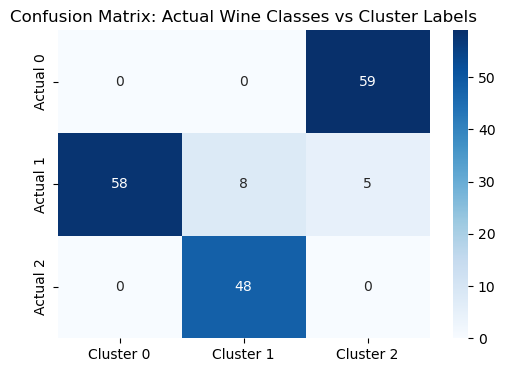

In [4]:
# Confusion matrix (only for n_clusters = 3)
conf_matrix = confusion_matrix(y, best_labels)
conf_df = pd.DataFrame(conf_matrix,
                       index=[f"Actual {i}" for i in np.unique(y)],
                       columns=[f"Cluster {i}" for i in np.unique(best_labels)])

plt.figure(figsize=(6, 4))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Actual Wine Classes vs Cluster Labels")
plt.show()

In [5]:
def remap_clusters(cluster_labels, true_labels):
    """
    Reassigns cluster labels to match the majority true label in each cluster.
    
    Parameters:
    - cluster_labels: array-like, predicted cluster labels from an unsupervised algorithm
    - true_labels: array-like, actual class labels (used only for evaluation)
    
    Returns:
    - remapped_labels: array of cluster labels aligned with true labels
    - mapping: dict showing how original cluster labels were mapped
    """
    label_map = {}
    for cluster in np.unique(cluster_labels):
        mask = cluster_labels == cluster
        majority_label = mode(true_labels[mask], keepdims=False).mode
        label_map[cluster] = majority_label
    
    remapped_labels = np.vectorize(label_map.get)(cluster_labels)
    return remapped_labels, label_map

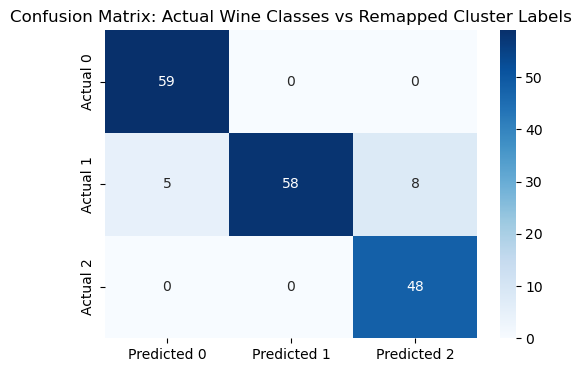

In [6]:
# Confusion matrix (only for n_clusters = 3) after cluster remapping
remapped_labels, label_map = remap_clusters(best_labels, y)
conf_matrix = confusion_matrix(y, remapped_labels)
conf_df = pd.DataFrame(conf_matrix,
                       index=[f"Actual {i}" for i in np.unique(y)],
                       columns=[f"Predicted {i}" for i in np.unique(remapped_labels)])

plt.figure(figsize=(6, 4))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Actual Wine Classes vs Remapped Cluster Labels")
plt.show()

#### Analaysis
- The confusion matrix heatmap compares True labels and Predicted cluster labels
- But the cluster labels (e.g., 0, 1, 2) are arbitrary — they don't match true classes by default.
- So remapping cluster names to the true labes is required to better interpret the heatmaps
- We can clearly see diagonal dominance in the second heatmap. Each predicted cluster now matches a real class
- The first heatmap, no diagonal dominance is observed which can be misinterpreted as bad performanace

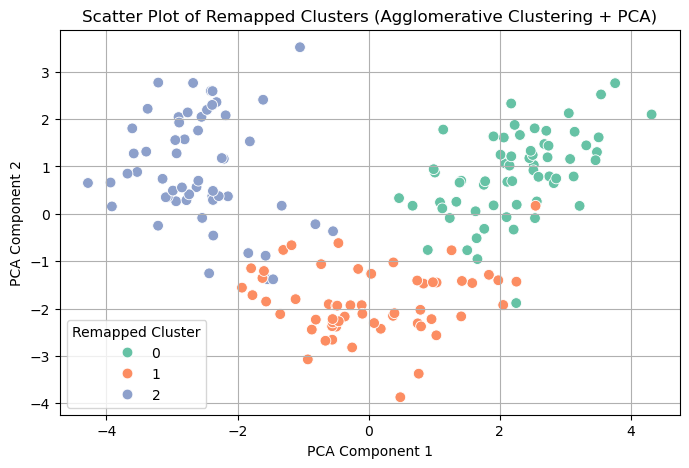

In [8]:
# Scattering Plot
# Apply PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=remapped_labels, palette='Set2', s=60)
plt.title("Scatter Plot of Remapped Clusters (Agglomerative Clustering + PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Remapped Cluster")
plt.grid(True)
plt.show()

In [ ]:
# Use Ward's method for linkage (minimizes variance within clusters)
linked = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False,
           truncate_mode='level',  # Show only top levels
           p=30)  # Adjust this value to zoom into more or fewer merges

plt.title("Dendrogram for Wine Dataset (Ward Linkage)")
plt.xlabel("Sample Index or (Cluster Size)")
plt.ylabel("Euclidean Distance")
plt.grid(True)
plt.show()

3. ### DBSCAN Clustering

In [ ]:

# Step 2: Parameter grid for DBSCAN
eps_values = [0.5, 1.0, 1.5]
min_samples_values = [3, 5, 10]

results = []
# Step 3: Loop through parameter combinations
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_pca)

        # Number of clusters (excluding noise)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # Evaluate only if more than 1 cluster
        if n_clusters > 1:
            silhouette = silhouette_score(X_pca, labels)
            homogeneity = homogeneity_score(y, labels)
            completeness = completeness_score(y, labels)
        else:
            silhouette = homogeneity = completeness = np.nan

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette_score': silhouette,
            'homogeneity_score': homogeneity,
            'completeness_score': completeness
        })

        # Step 4: Plot clusters
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='Set2', s=60, legend='full')
        plt.title(f'DBSCAN: eps={eps}, min_samples={min_samples}\nClusters={n_clusters}, Noise={n_noise}')
        plt.xlabel('PCA Component 1')
        plt.ylabel('PCA Component 2')
        plt.legend(title='Cluster')
        plt.grid(True)
        plt.show()

# Step 5: Display Results
results_df = pd.DataFrame(results)
print("DBSCAN Evaluation Metrics")
display(results_df)